# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFScar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>
  
<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final</center>

**Nome**: Anne Mari Suenaga Sakai   -   **RA**: 822304

**Nome**: Felipe Jun Nishitani   -   **RA**: 

**Nome**: Lucas Pereira Goes   -   **RA**: 

---
## Visão geral

Este notebook desenvolve um sistema de categorização automática de documentos jurídicos do corpus VICTOR. O objetivo é classificar cada documento em uma das cinco categorias válidas:

| Rótulo | Categoria |
|---:|---|
| 0 | Acórdão |
| 1 | Agravo de Recurso Extraordinário (ARE) |
| 2 | Despacho |
| 3 | Recurso Extraordinário (RE) |
| 4 | Sentença |

As amostras com `Category = -1` são documentos sem rótulo. Elas não constituem uma sexta classe: serão tratadas por pseudo-rotulagem e nunca entrarão no conjunto de validação.

O fluxo experimental segue as etapas pedidas no enunciado: análise exploratória, pré-processamento, tarefa básica de PLN/extração de atributos, representações computacionais, modelos clássicos e neurais, análise dos resultados e geração da submissão.


---
## 1. Análise exploratória

Esta seção examina a estrutura da base, a qualidade dos dados, o desbalanceamento, o tamanho dos documentos e o vocabulário jurídico. As contagens lexicais usam apenas uma normalização mínima interna; a transformação oficial dos textos é definida posteriormente na seção de pré-processamento.


In [16]:
# 1.1 Importações, configuração e leitura da base
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

RANDOM_STATE = 42
CLASSES_VALIDAS = [0, 1, 2, 3, 4]
MAPA_CLASSES = {
    0: "Acórdão",
    1: "Agravo de Recurso Extraordinário (ARE)",
    2: "Despacho",
    3: "Recurso Extraordinário (RE)",
    4: "Sentença",
}

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
warnings.filterwarnings("ignore", category=FutureWarning)

CAMINHO_TREINO = Path("train.csv")
CAMINHO_TESTE = Path("test.csv")
CAMINHO_SUBMISSION = Path("submission.csv")

if not CAMINHO_TREINO.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {CAMINHO_TREINO.resolve()}")

df = pd.read_csv(CAMINHO_TREINO)
df.head()


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3


In [17]:
# 1.2 Estrutura e significado dos atributos
descricao_atributos = pd.DataFrame({
    "Atributo": ["Id", "Body", "Category"],
    "Significado": [
        "Identificador único do documento.",
        "Texto extraído das páginas do documento jurídico.",
        "Rótulo da categoria; -1 indica amostra não rotulada.",
    ],
})

print(f"Dimensões da base: {df.shape[0]} linhas e {df.shape[1]} colunas")
display(descricao_atributos)
display(df.head())

print("\nTipos e preenchimento:")
df.info()


Dimensões da base: 22680 linhas e 3 colunas


,Atributo,Significado
0,Id,Identificador único do documento.
1,Body,Texto extraído das páginas do documento jurídico.
2,Category,Rótulo da categoria; -1 indica amostra não rot...


,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera ...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimen...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o p...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazen...",3



Tipos e preenchimento:
<class 'pandas.DataFrame'>
RangeIndex: 22680 entries, 0 to 22679
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Id        22680 non-null  int64
 1   Body      22680 non-null  str  
 2   Category  22680 non-null  int64
dtypes: int64(2), str(1)
memory usage: 531.7 KB


In [18]:
# 1.3 Qualidade dos dados
diagnostico = pd.DataFrame({
    "valores_nulos": df.isna().sum(),
    "percentual_nulos": (100 * df.isna().mean()).round(2),
    "valores_unicos": df.nunique(dropna=False),
})

display(diagnostico)
print("IDs duplicados:", int(df["Id"].duplicated().sum()))
print("Textos duplicados:", int(df["Body"].duplicated().sum()))

grupos_texto = df.groupby("Body")["Category"].agg(["size", "nunique"])
print(
    "Grupos de texto repetido:",
    int((grupos_texto["size"] > 1).sum()),
)
print(
    "Grupos repetidos com rótulos conflitantes:",
    int((grupos_texto["nunique"] > 1).sum()),
)


,valores_nulos,percentual_nulos,valores_unicos
Id,0,0.0,22680
Body,0,0.0,11497
Category,0,0.0,6


IDs duplicados: 0
Textos duplicados: 11183
Grupos de texto repetido: 2514
Grupos repetidos com rótulos conflitantes: 884


,classe,quantidade,percentual
0,Recurso Extraordinário (RE),12876,56.77
1,Agravo de Recurso Extraordinário (ARE),3529,15.56
2,Sentença,2903,12.80
3,Não rotulado (-1),2268,10.00
4,Acórdão,665,2.93
5,Despacho,439,1.94


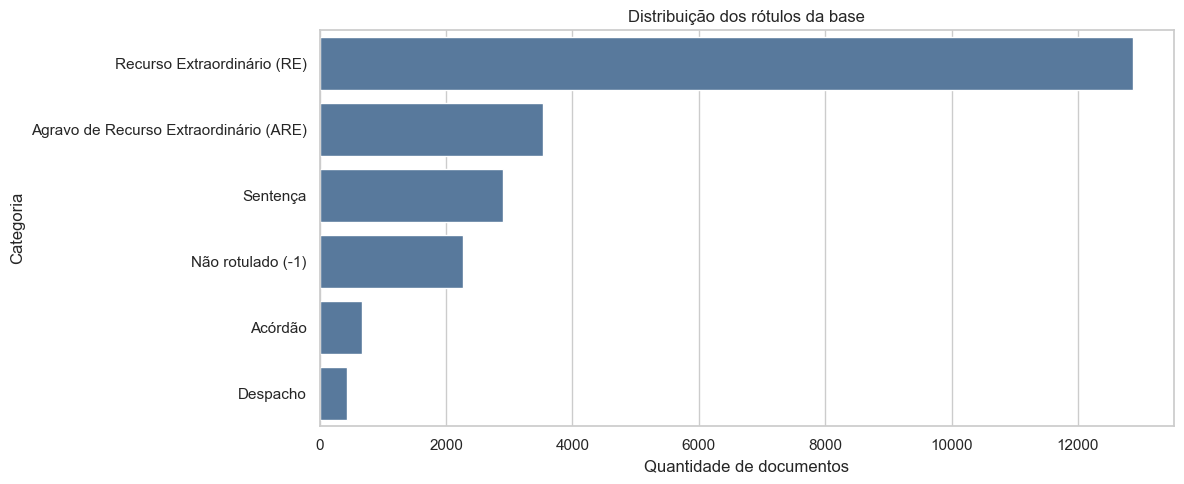

In [19]:
# 1.4 Distribuição dos rótulos, incluindo as amostras não rotuladas
df["Category_nome"] = df["Category"].map(MAPA_CLASSES).fillna("Não rotulado (-1)")

dist_classes = (
    df["Category_nome"]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .reset_index(name="quantidade")
)
dist_classes["percentual"] = (
    100 * dist_classes["quantidade"] / len(df)
).round(2)

display(dist_classes)

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    y="Category_nome",
    order=df["Category_nome"].value_counts().index,
    color="#4C78A8",
)
plt.title("Distribuição dos rótulos da base")
plt.xlabel("Quantidade de documentos")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


In [20]:
# 1.5 Desbalanceamento entre as cinco classes válidas
contagens_validas = (
    df.loc[df["Category"].isin(CLASSES_VALIDAS), "Category"]
    .value_counts()
    .reindex(CLASSES_VALIDAS, fill_value=0)
)

razao_desbalanceamento = (
    contagens_validas.max() / contagens_validas[contagens_validas > 0].min()
)

display(
    contagens_validas.rename(index=MAPA_CLASSES)
    .rename("quantidade")
    .to_frame()
)
print(f"Razão entre a maior e a menor classe: {razao_desbalanceamento:.2f}")
print(
    "A avaliação priorizará Macro F1, pois essa métrica atribui o mesmo peso "
    "a cada classe, independentemente de sua frequência."
)


,quantidade
Category,
Acórdão,665
Agravo de Recurso Extraordinário (ARE),3529
Despacho,439
Recurso Extraordinário (RE),12876
Sentença,2903


Razão entre a maior e a menor classe: 29.33
A avaliação priorizará Macro F1, pois essa métrica atribui o mesmo peso a cada classe, independentemente de sua frequência.


,qtd_caracteres,qtd_palavras,qtd_sentencas
count,22680.000000,22680.000000,22680.0
mean,1758.236772,216.426058,0.0
std,750.062347,93.088142,0.0
min,4.000000,1.000000,0.0
25%,1293.000000,159.000000,0.0
50%,1715.000000,209.000000,0.0
75%,2177.000000,268.000000,0.0
90%,2678.000000,327.000000,0.0
95%,3067.000000,380.000000,0.0
99%,3684.000000,465.000000,0.0


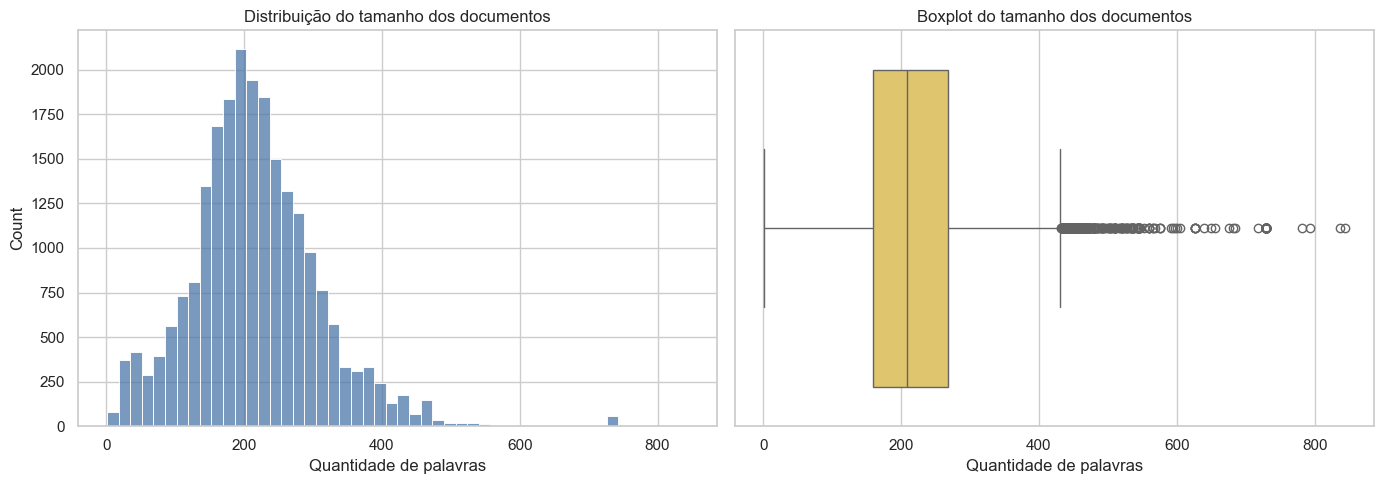

In [21]:
# 1.6 Medidas descritivas do tamanho dos documentos
texto_original = df["Body"].fillna("").astype(str)
df["qtd_caracteres"] = texto_original.str.len()
df["qtd_palavras"] = texto_original.str.split().str.len()
df["qtd_sentencas"] = texto_original.str.count(r"[.!?]+")

display(
    df[["qtd_caracteres", "qtd_palavras", "qtd_sentencas"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["qtd_palavras"], bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribuição do tamanho dos documentos")
axes[0].set_xlabel("Quantidade de palavras")

sns.boxplot(data=df, x="qtd_palavras", ax=axes[1], color="#F2CF5B")
axes[1].set_title("Boxplot do tamanho dos documentos")
axes[1].set_xlabel("Quantidade de palavras")

plt.tight_layout()
plt.show()


,count,mean,median,std,min,max
Category_nome,,,,,,
Acórdão,665,251.54,262.0,114.34,19,576
Agravo de Recurso Extraordinário (ARE),3529,195.20,181.0,90.09,1,685
Despacho,439,149.04,152.0,102.66,14,844
Recurso Extraordinário (RE),12876,213.88,206.0,87.94,4,781
Sentença,2903,254.39,243.0,94.12,13,837


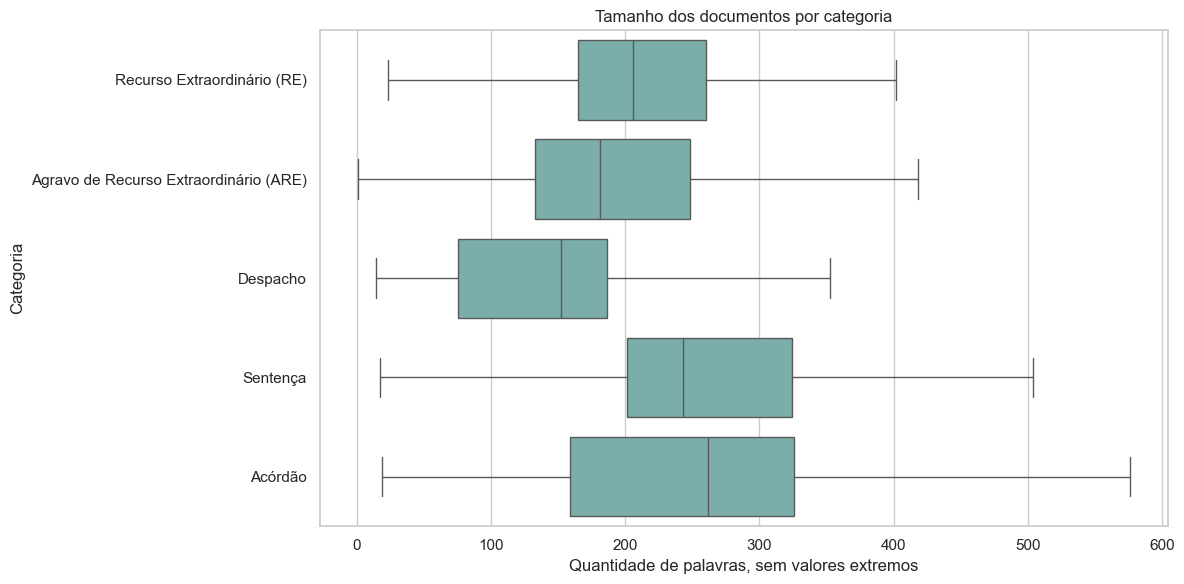

In [22]:
# 1.7 Tamanho dos textos por categoria válida
df_rotulos_validos_eda = df[df["Category"].isin(CLASSES_VALIDAS)].copy()

estatisticas_por_classe = (
    df_rotulos_validos_eda
    .groupby("Category_nome")["qtd_palavras"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)
display(estatisticas_por_classe)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_rotulos_validos_eda,
    y="Category_nome",
    x="qtd_palavras",
    color="#72B7B2",
    showfliers=False,
)
plt.title("Tamanho dos documentos por categoria")
plt.xlabel("Quantidade de palavras, sem valores extremos")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()


,termo,frequencia
0,rio,54583
1,federal,33760
2,ria,29127
3,recurso,27826
4,lei,25684
5,pela,24809
6,geral,23459
7,fazenda,20255
8,benefã,19814
9,contribuiã,19636


Vocabulário observado com min_df=5: 14702 termos


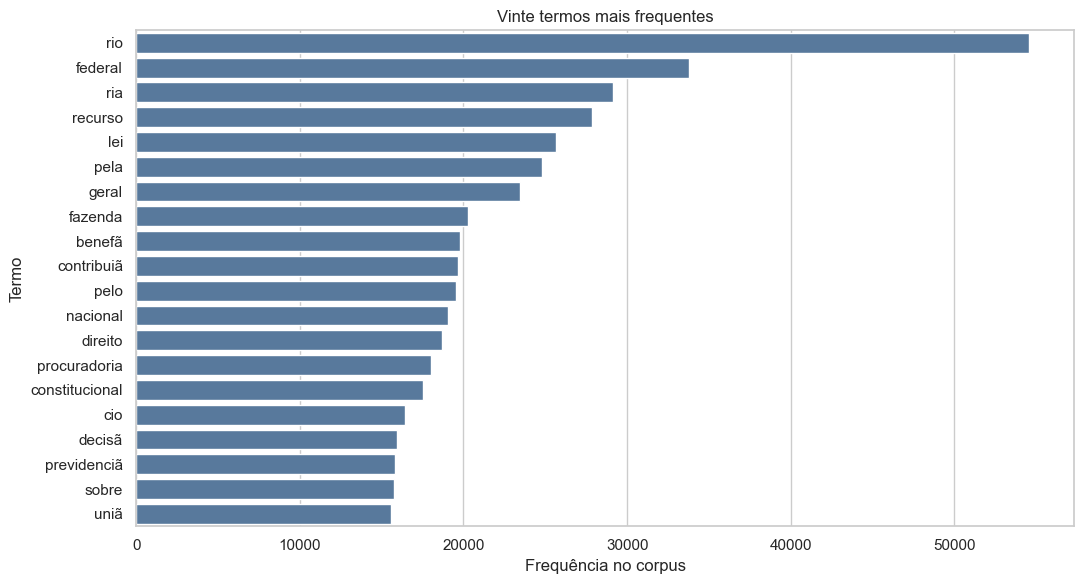

In [23]:
# 1.8 Vocabulário mais frequente no corpus
STOPWORDS_EDA = {
    "a", "o", "os", "as", "um", "uma", "uns", "umas", "de", "do", "da",
    "dos", "das", "em", "no", "na", "nos", "nas", "por", "para", "com",
    "sem", "e", "ou", "mas", "que", "se", "ao", "aos", "é", "são",
    "foi", "ser", "sua", "seu", "suas", "seus", "não", "como", "mais",
    "este", "esta", "esse", "essa", "isso", "lhe", "lhes",
}

vectorizer_eda = CountVectorizer(
    lowercase=True,
    stop_words=list(STOPWORDS_EDA),
    min_df=5,
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{3,}\b",
)
X_contagens_eda = vectorizer_eda.fit_transform(texto_original)
termos_eda = np.asarray(
    vectorizer_eda.get_feature_names_out()
    if hasattr(vectorizer_eda, "get_feature_names_out")
    else vectorizer_eda.get_feature_names()
)
frequencias_eda = np.asarray(X_contagens_eda.sum(axis=0)).ravel()

freq_df = (
    pd.DataFrame({"termo": termos_eda, "frequencia": frequencias_eda})
    .sort_values("frequencia", ascending=False)
    .reset_index(drop=True)
)

display(freq_df.head(25))
print(f"Vocabulário observado com min_df=5: {len(termos_eda)} termos")

plt.figure(figsize=(11, 6))
sns.barplot(data=freq_df.head(20), x="frequencia", y="termo", color="#4C78A8")
plt.title("Vinte termos mais frequentes")
plt.xlabel("Frequência no corpus")
plt.ylabel("Termo")
plt.tight_layout()
plt.show()


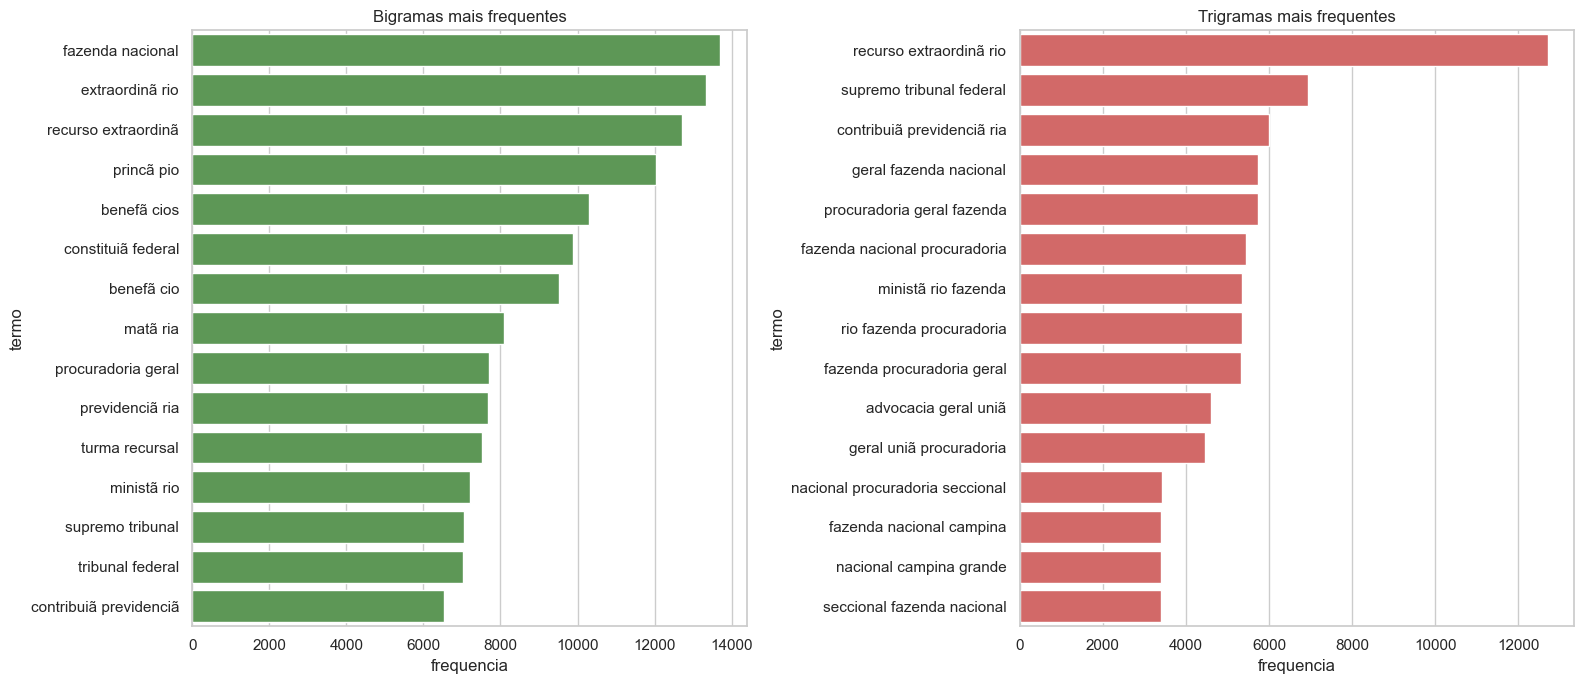

In [24]:
# 1.9 Bigramas e trigramas mais frequentes
def obter_ngramas(textos, intervalo, top_n=15):
    vetorizador = CountVectorizer(
        lowercase=True,
        stop_words=list(STOPWORDS_EDA),
        ngram_range=intervalo,
        min_df=3,
        token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{3,}\b",
    )
    matriz = vetorizador.fit_transform(textos)
    termos = np.asarray(
        vetorizador.get_feature_names_out()
        if hasattr(vetorizador, "get_feature_names_out")
        else vetorizador.get_feature_names()
    )
    frequencias = np.asarray(matriz.sum(axis=0)).ravel()
    return (
        pd.DataFrame({"termo": termos, "frequencia": frequencias})
        .sort_values("frequencia", ascending=False)
        .head(top_n)
    )

bigramas = obter_ngramas(texto_original, (2, 2))
trigramas = obter_ngramas(texto_original, (3, 3))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=bigramas, x="frequencia", y="termo", ax=axes[0], color="#54A24B")
axes[0].set_title("Bigramas mais frequentes")
sns.barplot(data=trigramas, x="frequencia", y="termo", ax=axes[1], color="#E45756")
axes[1].set_title("Trigramas mais frequentes")
plt.tight_layout()
plt.show()


**Síntese da análise exploratória.** A base contém textos jurídicos longos e heterogêneos, além de documentos sem rótulo (`-1`). A distribuição das classes e a diferença entre os tamanhos dos documentos justificam o uso de divisão estratificada e de métricas macro. Termos e n-gramas recorrentes também indicam que representações baseadas em frequência, como Bag of Words e TF-IDF, constituem baselines adequadas.


---
## 2. Pré-processamento

O pré-processamento busca reduzir ruídos de OCR e padronizar o texto, preservando acentos e palavras jurídicas relevantes. Números são removidos da representação lexical para reduzir números processuais e datas muito específicos; em paralelo, padrões numéricos relevantes serão contabilizados como atributos de extração de informação.

O texto original é mantido na coluna `Body`, enquanto `Body_preprocessado` armazena a versão usada nos modelos.


In [25]:
# 2.1 Tratamento estrutural
print("Dimensão antes do tratamento:", df.shape)

df = df.dropna(subset=["Id", "Body", "Category"]).copy()
df["Body"] = df["Body"].astype(str)
df["Category"] = pd.to_numeric(df["Category"], errors="coerce")
df = df.dropna(subset=["Category"]).copy()
df["Category"] = df["Category"].astype(int)

df = df.drop_duplicates(subset=["Id"], keep="first")

# Textos idênticos podem pertencer a documentos e classes diferentes.
# Eles são mantidos; o protocolo experimental os agrupa para evitar que
# uma cópia apareça no treino e outra na validação.

rotulos_permitidos = set(CLASSES_VALIDAS + [-1])
rotulos_invalidos = set(df["Category"].unique()) - rotulos_permitidos
if rotulos_invalidos:
    raise ValueError(f"Foram encontrados rótulos inesperados: {rotulos_invalidos}")

print("Dimensão depois do tratamento:", df.shape)
print(df["Category"].value_counts().sort_index())


Dimensão antes do tratamento: (22680, 7)
Dimensão depois do tratamento: (22680, 7)
Category
-1     2268
 0      665
 1     3529
 2      439
 3    12876
 4     2903
Name: count, dtype: int64


In [26]:
# 2.2 Stopwords e funções de normalização
STOPWORDS_PT = STOPWORDS_EDA | {
    "sob", "sobre", "entre", "às", "também", "menos", "estes", "estas",
    "esses", "essas", "isto", "aquele", "aquela", "aqueles", "aquelas",
    "me", "te", "vos", "foram", "era", "eram", "estar", "meu", "minha",
    "meus", "minhas", "muito", "muita", "já", "ainda", "então", "após",
    "antes", "quando", "onde", "qual", "quais", "quem", "cujo", "cuja",
    "cujos", "cujas",
}

def normalizar_texto(
    texto,
    remover_numeros=True,
    remover_stopwords=True,
    tamanho_minimo=3,
):
    texto = unicodedata.normalize("NFC", str(texto).lower())
    texto = re.sub(r"https?://\S+|www\.\S+", " ", texto)
    texto = re.sub(r"[_\-]{3,}", " ", texto)

    if remover_numeros:
        texto = re.sub(r"\d+", " ", texto)

    texto = re.sub(r"[^a-záàâãéèêíïóôõöúçñ\s]", " ", texto)
    tokens = re.findall(r"\b[a-záàâãéèêíïóôõöúçñ]+\b", texto)

    if remover_stopwords:
        tokens = [token for token in tokens if token not in STOPWORDS_PT]

    tokens = [token for token in tokens if len(token) >= tamanho_minimo]
    return " ".join(tokens)


In [27]:
# 2.3 Aplicação e verificação do pré-processamento
df["Body_preprocessado"] = df["Body"].map(normalizar_texto)

# Textos eventualmente esvaziados pela limpeza são removidos.
vazios = df["Body_preprocessado"].str.strip().eq("")
print("Textos vazios após o pré-processamento:", int(vazios.sum()))
df = df.loc[~vazios].copy()

df["qtd_palavras_original"] = df["Body"].str.split().str.len()
df["qtd_palavras_preprocessado"] = df["Body_preprocessado"].str.split().str.len()

display(
    df[["qtd_palavras_original", "qtd_palavras_preprocessado"]]
    .describe()
    .round(2)
)

display(df[["Body", "Body_preprocessado"]].head(3))


Textos vazios após o pré-processamento: 6


,qtd_palavras_original,qtd_palavras_preprocessado
count,22674.00,22674.00
mean,216.48,195.18
std,93.03,83.02
min,4.00,3.00
25%,160.00,145.00
50%,209.00,189.00
75%,268.00,239.00
max,844.00,780.00


,Body,Body_preprocessado
0,"{""conclusÃ£o diante exposto recorrente espera ...",conclusã diante exposto recorrente espera conf...
1,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos t...",artigo gecen gacen serã devidas titulares empr...
2,"{""seguir desacerto decisÃ£o que negou seguimen...",seguir desacerto decisã negou seguimento recur...


---
## 3. Extração de informações jurídicas

Como tarefa básica de PLN, foi implementada uma etapa de **extração de informação (IE)** baseada em padrões. Ela contabiliza referências a artigos, leis, números processuais no padrão CNJ, citações constitucionais e termos associados às partes do processo. Esses atributos permitem testar se sinais estruturais complementam a representação lexical.


In [28]:
# 3.1 Atributos jurídicos extraídos por documento
PADROES_JURIDICOS = {
    "qtd_artigos": r"\bart\.?\s*\d+",
    "qtd_leis": r"\blei\s+(?:n[º°o]\.?\s*)?\d+",
    "qtd_processos_cnj": r"\b\d{7}-\d{2}\.\d{4}\.\d\.\d{2}\.\d{4}\b",
    "qtd_constituicao": r"\b(?:constituição|constitucional|cf[/\s]?88)\b",
    "qtd_recorrente": r"\brecorrente\b",
    "qtd_recorrido": r"\brecorrido\b",
    "qtd_relator": r"\brelator(?:a)?\b",
}

def extrair_atributos_juridicos(textos):
    linhas = []
    for texto in textos.fillna("").astype(str).str.lower():
        atributos = {
            nome: len(re.findall(padrao, texto, flags=re.IGNORECASE))
            for nome, padrao in PADROES_JURIDICOS.items()
        }
        atributos["qtd_caracteres_log"] = np.log1p(len(texto))
        atributos["qtd_palavras_log"] = np.log1p(len(texto.split()))
        linhas.append(atributos)
    return pd.DataFrame(linhas, index=textos.index)

atributos_juridicos = extrair_atributos_juridicos(df["Body"])
display(atributos_juridicos.describe().round(2))


,qtd_artigos,qtd_leis,qtd_processos_cnj,qtd_constituicao,qtd_recorrente,qtd_recorrido,qtd_relator,qtd_caracteres_log,qtd_palavras_log
count,22674.0,22674.0,22674.0,22674.00,22674.00,22674.00,22674.00,22674.00,22674.00
mean,0.0,0.0,0.0,0.77,0.23,0.23,0.27,7.35,5.27
std,0.0,0.0,0.0,1.16,0.65,0.57,0.68,0.56,0.54
min,0.0,0.0,0.0,0.00,0.00,0.00,0.00,3.37,1.61
25%,0.0,0.0,0.0,0.00,0.00,0.00,0.00,7.17,5.08
50%,0.0,0.0,0.0,0.00,0.00,0.00,0.00,7.45,5.35
75%,0.0,0.0,0.0,1.00,0.00,0.00,0.00,7.69,5.59
max,0.0,0.0,0.0,12.00,9.00,9.00,7.00,8.83,6.74


---
## 4. Protocolo experimental e pseudo-rotulagem

Primeiro, somente as amostras com rótulos humanos (`0` a `4`) são divididas em treino e validação. A divisão é feita por grupos de texto idêntico: todas as ocorrências do mesmo conteúdo permanecem no mesmo lado, evitando que uma duplicata no treino facilite artificialmente a classificação de sua cópia na validação. Entre várias divisões candidatas, escolhe-se a que melhor preserva a distribuição global das classes.

Em seguida, um modelo auxiliar treinado apenas na parcela de treino humano estima probabilidades para os documentos `-1`. Somente previsões com confiança mínima são incorporadas ao treino. Esse protocolo evita vazamento de informação e produz uma avaliação mais realista.


In [29]:
# 4.1 Divisão por grupos apenas dos dados rotulados
from sklearn.model_selection import GroupShuffleSplit

TEXT_COL = "Body_preprocessado"
TARGET_COL = "Category"

df_rotulado = df[df[TARGET_COL].isin(CLASSES_VALIDAS)].copy()
df_nao_rotulado = df[df[TARGET_COL].eq(-1)].copy()

distribuicao_global = (
    df_rotulado[TARGET_COL]
    .value_counts(normalize=True)
    .reindex(CLASSES_VALIDAS, fill_value=0)
)

separador = GroupShuffleSplit(
    n_splits=30,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

melhor_divisao = None
melhor_desvio = np.inf

for pos_treino, pos_validacao in separador.split(
    df_rotulado,
    y=df_rotulado[TARGET_COL],
    groups=df_rotulado["Body"],
):
    y_candidato = df_rotulado.iloc[pos_validacao][TARGET_COL]
    if set(y_candidato.unique()) != set(CLASSES_VALIDAS):
        continue

    distribuicao_candidata = (
        y_candidato.value_counts(normalize=True)
        .reindex(CLASSES_VALIDAS, fill_value=0)
    )
    desvio = np.abs(distribuicao_candidata - distribuicao_global).sum()

    if desvio < melhor_desvio:
        melhor_desvio = desvio
        melhor_divisao = (pos_treino, pos_validacao)

if melhor_divisao is None:
    raise RuntimeError("Não foi possível criar uma validação com todas as classes.")

pos_treino, pos_validacao = melhor_divisao
indices_treino = df_rotulado.iloc[pos_treino].index
indices_validacao = df_rotulado.iloc[pos_validacao].index

df_treino_humano = df_rotulado.loc[indices_treino].copy()
df_validacao = df_rotulado.loc[indices_validacao].copy()

print("Treino com rótulos humanos:", df_treino_humano.shape)
print("Validação com rótulos humanos:", df_validacao.shape)
print("Documentos disponíveis para pseudo-rotulagem:", df_nao_rotulado.shape)
print(f"Desvio de distribuição da divisão escolhida: {melhor_desvio:.4f}")
print(
    "Textos compartilhados entre treino e validação:",
    len(set(df_treino_humano["Body"]) & set(df_validacao["Body"])),
)
print("\nClasses na validação:")
print(df_validacao[TARGET_COL].value_counts().sort_index())


Treino com rótulos humanos: (16507, 10)
Validação com rótulos humanos: (3901, 10)
Documentos disponíveis para pseudo-rotulagem: (2266, 10)
Desvio de distribuição da divisão escolhida: 0.0103
Textos compartilhados entre treino e validação: 0

Classes na validação:
Category
0     130
1     691
2      84
3    2452
4     544
Name: count, dtype: int64


In [30]:
# 4.2 Pseudo-rotulagem com TF-IDF e Regressão Logística
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

LIMIAR_CONFIANCA = 0.80

tfidf_pseudo = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

X_pseudo_treino = tfidf_pseudo.fit_transform(df_treino_humano[TEXT_COL])
y_pseudo_treino = df_treino_humano[TARGET_COL]

modelo_pseudo = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
modelo_pseudo.fit(X_pseudo_treino, y_pseudo_treino)

df_pseudo_confiavel = df_nao_rotulado.iloc[0:0].copy()
textos_validacao = set(df_validacao["Body"])
df_nao_rotulado_candidato = df_nao_rotulado[
    ~df_nao_rotulado["Body"].isin(textos_validacao)
].copy()

if not df_nao_rotulado_candidato.empty:
    X_sem_rotulo = tfidf_pseudo.transform(
        df_nao_rotulado_candidato[TEXT_COL]
    )
    probabilidades = modelo_pseudo.predict_proba(X_sem_rotulo)

    df_nao_rotulado_candidato["pseudo_Category"] = modelo_pseudo.classes_[
        probabilidades.argmax(axis=1)
    ]
    df_nao_rotulado_candidato["pseudo_confianca"] = probabilidades.max(axis=1)

    df_pseudo_confiavel = df_nao_rotulado_candidato[
        df_nao_rotulado_candidato["pseudo_confianca"] >= LIMIAR_CONFIANCA
    ].copy()
    df_pseudo_confiavel[TARGET_COL] = (
        df_pseudo_confiavel["pseudo_Category"].astype(int)
    )

print(f"Limiar de confiança: {LIMIAR_CONFIANCA:.0%}")
print(
    "Não rotulados excluídos por coincidirem com a validação:",
    len(df_nao_rotulado) - len(df_nao_rotulado_candidato),
)
print("Pseudo-rótulos aceitos:", len(df_pseudo_confiavel))
print(
    "Pseudo-rótulos rejeitados por baixa confiança:",
    len(df_nao_rotulado_candidato) - len(df_pseudo_confiavel),
)

if not df_pseudo_confiavel.empty:
    display(
        df_pseudo_confiavel[TARGET_COL]
        .value_counts()
        .sort_index()
        .rename(index=MAPA_CLASSES)
        .rename("quantidade")
        .to_frame()
    )


Limiar de confiança: 80%
Não rotulados excluídos por coincidirem com a validação: 259
Pseudo-rótulos aceitos: 1136
Pseudo-rótulos rejeitados por baixa confiança: 871


,quantidade
Category,
Acórdão,57
Agravo de Recurso Extraordinário (ARE),203
Despacho,28
Recurso Extraordinário (RE),616
Sentença,232


In [31]:
# 4.3 Base expandida: pseudo-rótulos entram somente no treino
colunas_base = df_treino_humano.columns
df_treino_expandido = pd.concat(
    [
        df_treino_humano,
        df_pseudo_confiavel.reindex(columns=colunas_base),
    ],
    ignore_index=True,
)

X_train = df_treino_expandido[TEXT_COL].astype(str)
y_train = df_treino_expandido[TARGET_COL].astype(int)
X_val = df_validacao[TEXT_COL].astype(str)
y_val = df_validacao[TARGET_COL].astype(int)

assert set(y_train.unique()).issubset(CLASSES_VALIDAS)
assert set(y_val.unique()).issubset(CLASSES_VALIDAS)

print("Treino final:", X_train.shape)
print("Validação isolada:", X_val.shape)


Treino final: (17643,)
Validação isolada: (3901,)


---
## 5. Representações computacionais

São comparadas três representações:

1. **Bag of Words:** contagem de unigramas e bigramas.
2. **TF-IDF:** ponderação que reduz a influência de termos muito frequentes.
3. **TF-IDF + SVD:** projeção densa usada pela rede neural MLP.

Também é criada uma versão de TF-IDF combinada aos atributos jurídicos extraídos. Todos os vetorizadores são ajustados exclusivamente no treino.


In [32]:
# 5.1 Bag of Words e TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    dtype=np.int32,
)
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    dtype=np.float32,
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_val_bow = bow_vectorizer.transform(X_val)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("Bag of Words:", X_train_bow.shape, X_val_bow.shape)
print("TF-IDF:", X_train_tfidf.shape, X_val_tfidf.shape)


Bag of Words: (17643, 30000) (3901, 30000)
TF-IDF: (17643, 50000) (3901, 50000)


In [33]:
# 5.2 Combinação de TF-IDF com atributos jurídicos
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler

atrib_train = extrair_atributos_juridicos(
    df_treino_expandido["Body"]
).to_numpy(dtype=np.float32)
atrib_val = extrair_atributos_juridicos(
    df_validacao["Body"]
).to_numpy(dtype=np.float32)

scaler_atributos = StandardScaler()
atrib_train = scaler_atributos.fit_transform(atrib_train)
atrib_val = scaler_atributos.transform(atrib_val)

X_train_tfidf_ie = hstack(
    [X_train_tfidf, csr_matrix(atrib_train)],
    format="csr",
)
X_val_tfidf_ie = hstack(
    [X_val_tfidf, csr_matrix(atrib_val)],
    format="csr",
)

print("TF-IDF + atributos jurídicos:", X_train_tfidf_ie.shape)


TF-IDF + atributos jurídicos: (17643, 50009)


In [34]:
# 5.3 Representação densa TF-IDF + SVD
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

n_componentes = min(300, X_train_tfidf.shape[0] - 1, X_train_tfidf.shape[1] - 1)
svd = TruncatedSVD(n_components=n_componentes, random_state=RANDOM_STATE)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)

scaler_svd = StandardScaler()
X_train_svd = scaler_svd.fit_transform(X_train_svd).astype(np.float32)
X_val_svd = scaler_svd.transform(X_val_svd).astype(np.float32)

print("Representação densa:", X_train_svd.shape, X_val_svd.shape)
print(f"Variância explicada acumulada: {svd.explained_variance_ratio_.sum():.4f}")


Representação densa: (17643, 300) (3901, 300)
Variância explicada acumulada: 0.5792


---
## 6. Modelos e registro dos experimentos

São avaliados Naive Bayes, Regressão Logística e SVM linear nas representações esparsas. A MLP, com duas camadas ocultas, funciona como baseline neural sobre a representação densa.

As métricas são apenas registradas nesta seção. Tabelas, gráficos, matrizes de confusão e interpretação ficam concentrados na análise dos resultados.


In [35]:
# 6.1 Função de registro
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

resultados = []
predicoes_modelos = {}
modelos_treinados = {}

def registrar_resultado(nome_modelo, representacao, modelo, y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    chave = f"{nome_modelo} - {representacao}"
    resultados.append({
        "modelo": nome_modelo,
        "representacao": representacao,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    })
    predicoes_modelos[chave] = np.asarray(y_pred)
    modelos_treinados[chave] = modelo
    print("Registrado:", chave)


In [36]:
# 6.2 Modelos clássicos com Bag of Words
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

modelos_bow = {
    "Naive Bayes": MultinomialNB(),
    "Regressão Logística": LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "SVM Linear": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
}

for nome, modelo in modelos_bow.items():
    modelo.fit(X_train_bow, y_train)
    pred = modelo.predict(X_val_bow)
    registrar_resultado(nome, "Bag of Words", modelo, y_val, pred)


Registrado: Naive Bayes - Bag of Words
Registrado: Regressão Logística - Bag of Words
Registrado: SVM Linear - Bag of Words


/Users/annesakai/Downloads/PLN/template-implementacao/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [37]:
# 6.3 Modelos clássicos com TF-IDF
modelos_tfidf = {
    "Naive Bayes": MultinomialNB(),
    "Regressão Logística": LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "SVM Linear": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    ),
}

for nome, modelo in modelos_tfidf.items():
    modelo.fit(X_train_tfidf, y_train)
    pred = modelo.predict(X_val_tfidf)
    registrar_resultado(nome, "TF-IDF", modelo, y_val, pred)


Registrado: Naive Bayes - TF-IDF
Registrado: Regressão Logística - TF-IDF
Registrado: SVM Linear - TF-IDF


In [38]:
# 6.4 SVM com TF-IDF e atributos jurídicos
svm_ie = LinearSVC(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
)
svm_ie.fit(X_train_tfidf_ie, y_train)
pred_svm_ie = svm_ie.predict(X_val_tfidf_ie)

registrar_resultado(
    "SVM Linear",
    "TF-IDF + atributos jurídicos",
    svm_ie,
    y_val,
    pred_svm_ie,
)


Registrado: SVM Linear - TF-IDF + atributos jurídicos


In [39]:
# 6.5 Baseline neural: MLP sobre TF-IDF + SVD
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    batch_size=64,
    learning_rate_init=0.001,
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=4,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_svd, y_train)
pred_mlp = mlp.predict(X_val_svd)

registrar_resultado("MLP", "TF-IDF + SVD", mlp, y_val, pred_mlp)


Registrado: MLP - TF-IDF + SVD


**Limitação computacional.** O enunciado também sugere CNN/BiLSTM e adaptação de Transformers, como BERTimbau. Neste ambiente, o fine-tuning com `Trainer` exigiu a dependência adicional `accelerate` e apresentou custo elevado. Por isso, a execução reproduzível deste notebook concentra-se nos modelos acima; a MLP é tratada como baseline neural, e não como substituta conceitual de um Transformer.


---
## 7. Análise dos resultados

O **Macro F1** é a métrica principal, pois calcula o F1 de cada classe separadamente e depois atribui o mesmo peso a todas. Acurácia e F1 ponderado são apresentados como métricas complementares. A análise inclui desempenho por classe, matrizes de confusão e o teste de McNemar entre os dois melhores modelos.


In [40]:
# 7.1 Tabela e ranking dos experimentos
if not resultados:
    raise RuntimeError("Nenhum experimento foi registrado. Execute primeiro a seção 6.")

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
resultados_df.insert(
    0,
    "experimento",
    resultados_df["modelo"] + " - " + resultados_df["representacao"],
)

display(
    resultados_df.style.format({
        "accuracy": "{:.4f}",
        "precision_macro": "{:.4f}",
        "recall_macro": "{:.4f}",
        "f1_macro": "{:.4f}",
        "f1_weighted": "{:.4f}",
    })
)


,experimento,modelo,representacao,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,SVM Linear - TF-IDF,SVM Linear,TF-IDF,0.8811,0.8836,0.8794,0.8809,0.8818
1,SVM Linear - TF-IDF + atributos jurídicos,SVM Linear,TF-IDF + atributos jurídicos,0.8770,0.8796,0.8782,0.8784,0.8779
2,Regressão Logística - TF-IDF,Regressão Logística,TF-IDF,0.8567,0.8380,0.8816,0.8567,0.8606
3,MLP - TF-IDF + SVD,MLP,TF-IDF + SVD,0.8634,0.8550,0.8509,0.8522,0.8636
4,Regressão Logística - Bag of Words,Regressão Logística,Bag of Words,0.8521,0.8461,0.8500,0.8473,0.8541
5,SVM Linear - Bag of Words,SVM Linear,Bag of Words,0.8429,0.8369,0.8355,0.8351,0.8454
6,Naive Bayes - TF-IDF,Naive Bayes,TF-IDF,0.8054,0.8343,0.7205,0.7600,0.8056
7,Naive Bayes - Bag of Words,Naive Bayes,Bag of Words,0.6991,0.7392,0.7979,0.7438,0.7179


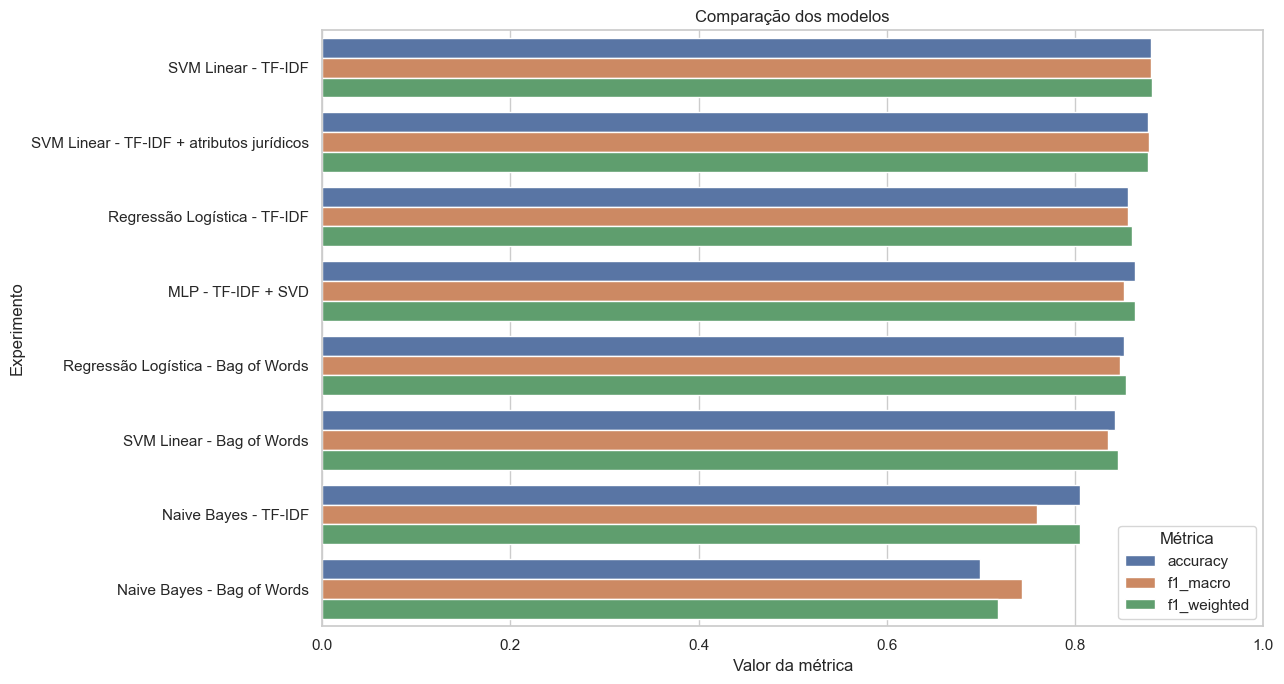

In [41]:
# 7.2 Comparação visual das métricas
metricas_long = resultados_df.melt(
    id_vars=["experimento"],
    value_vars=["accuracy", "f1_macro", "f1_weighted"],
    var_name="metrica",
    value_name="valor",
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=metricas_long,
    x="valor",
    y="experimento",
    hue="metrica",
)
plt.title("Comparação dos modelos")
plt.xlabel("Valor da métrica")
plt.ylabel("Experimento")
plt.xlim(0, 1)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()


In [42]:
# 7.3 Melhor modelo por Macro F1
from sklearn.metrics import classification_report, confusion_matrix

melhor_resultado = resultados_df.iloc[0]
melhor_experimento = melhor_resultado["experimento"]
y_pred_melhor = predicoes_modelos[melhor_experimento]

labels_classes = CLASSES_VALIDAS
nomes_classes = [MAPA_CLASSES[label] for label in labels_classes]

print("Melhor experimento:", melhor_experimento)
print(f"Macro F1: {melhor_resultado['f1_macro']:.4f}")
print(f"Accuracy: {melhor_resultado['accuracy']:.4f}")

relatorio_dict = classification_report(
    y_val,
    y_pred_melhor,
    labels=labels_classes,
    target_names=nomes_classes,
    output_dict=True,
    zero_division=0,
)

metricas_classes = (
    pd.DataFrame(relatorio_dict)
    .T
    .loc[nomes_classes, ["precision", "recall", "f1-score", "support"]]
)
display(metricas_classes.style.format("{:.4f}"))


Melhor experimento: SVM Linear - TF-IDF
Macro F1: 0.8809
Accuracy: 0.8811


,precision,recall,f1-score,support
Acórdão,0.9084,0.9154,0.9119,130.0000
Agravo de Recurso Extraordinário (ARE),0.7139,0.7511,0.7320,691.0000
Despacho,0.9610,0.8810,0.9193,84.0000
Recurso Extraordinário (RE),0.9197,0.9009,0.9102,2452.0000
Sentença,0.9149,0.9485,0.9314,544.0000


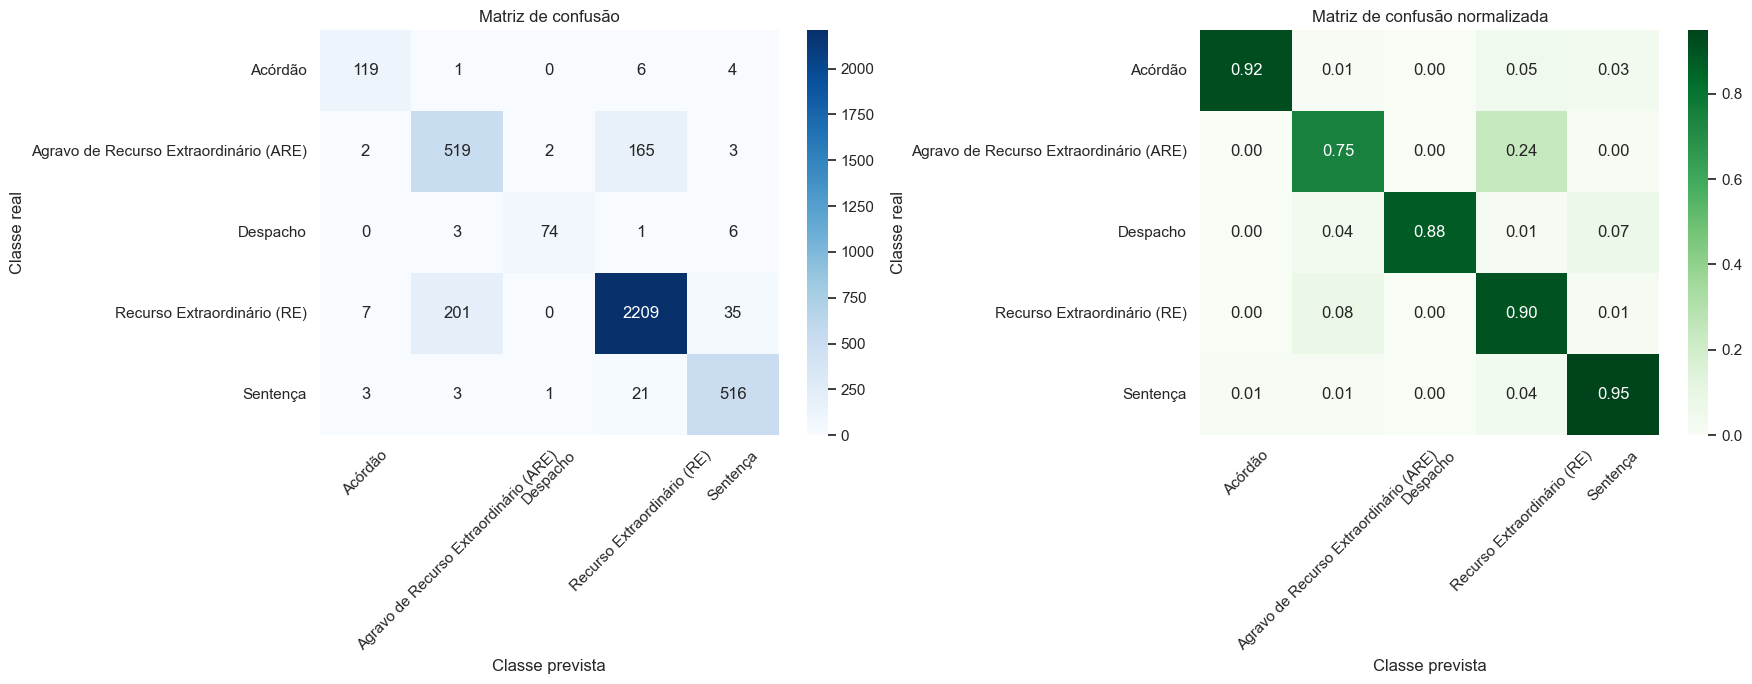

In [43]:
# 7.4 Matrizes de confusão absoluta e normalizada
matriz_absoluta = confusion_matrix(
    y_val,
    y_pred_melhor,
    labels=labels_classes,
)
matriz_normalizada = confusion_matrix(
    y_val,
    y_pred_melhor,
    labels=labels_classes,
    normalize="true",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(
    matriz_absoluta,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
    ax=axes[0],
)
axes[0].set_title("Matriz de confusão")
axes[0].set_xlabel("Classe prevista")
axes[0].set_ylabel("Classe real")

sns.heatmap(
    matriz_normalizada,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes,
    ax=axes[1],
)
axes[1].set_title("Matriz de confusão normalizada")
axes[1].set_xlabel("Classe prevista")
axes[1].set_ylabel("Classe real")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


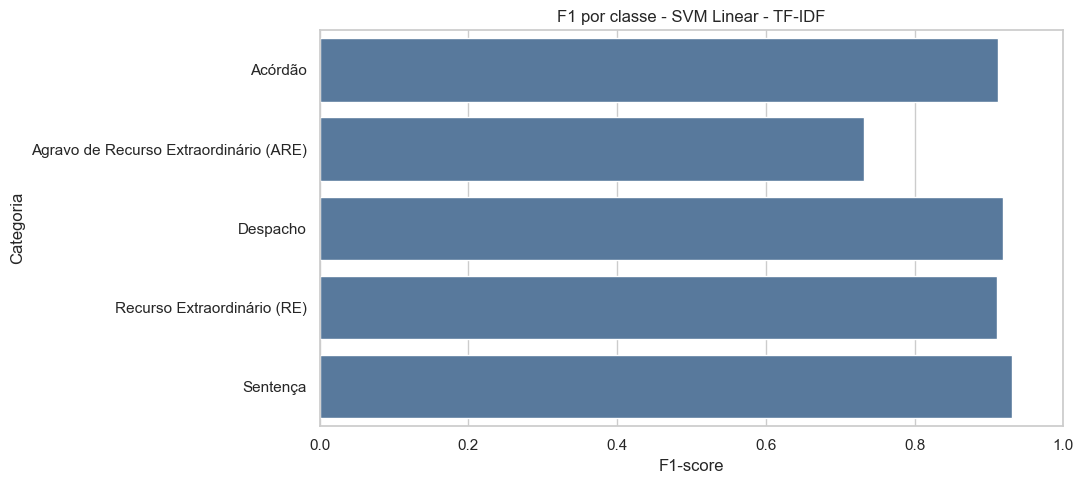

Maior F1 por classe: Sentença (0.9314)
Menor F1 por classe: Agravo de Recurso Extraordinário (ARE) (0.7320)
Diferença entre accuracy e Macro F1: 0.0001


In [44]:
# 7.5 F1 por classe e interpretação inicial
metricas_plot = (
    metricas_classes
    .reset_index()
    .rename(columns={"index": "classe", "f1-score": "f1_score"})
)

plt.figure(figsize=(11, 5))
sns.barplot(data=metricas_plot, x="f1_score", y="classe", color="#4C78A8")
plt.title(f"F1 por classe - {melhor_experimento}")
plt.xlabel("F1-score")
plt.ylabel("Categoria")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

classe_mais_dificil = metricas_plot.loc[metricas_plot["f1_score"].idxmin()]
classe_mais_facil = metricas_plot.loc[metricas_plot["f1_score"].idxmax()]

print(
    f"Maior F1 por classe: {classe_mais_facil['classe']} "
    f"({classe_mais_facil['f1_score']:.4f})"
)
print(
    f"Menor F1 por classe: {classe_mais_dificil['classe']} "
    f"({classe_mais_dificil['f1_score']:.4f})"
)

diferenca = melhor_resultado["accuracy"] - melhor_resultado["f1_macro"]
print(f"Diferença entre accuracy e Macro F1: {diferenca:.4f}")
if diferenca > 0.05:
    print(
        "A diferença sugere desempenho menos uniforme entre as classes; "
        "a matriz de confusão deve orientar a discussão dos erros."
    )


In [45]:
# 7.6 Teste de McNemar entre os dois melhores experimentos
import scipy.stats as stats

if len(resultados_df) >= 2:
    exp_1, exp_2 = resultados_df.loc[:1, "experimento"]
    pred_1 = predicoes_modelos[exp_1]
    pred_2 = predicoes_modelos[exp_2]

    correto_1 = pred_1 == y_val.to_numpy()
    correto_2 = pred_2 == y_val.to_numpy()
    b = int(np.sum(correto_1 & ~correto_2))
    c = int(np.sum(~correto_1 & correto_2))

    if b + c == 0:
        print("Os dois modelos acertaram e erraram exatamente os mesmos documentos.")
    else:
        if hasattr(stats, "binomtest"):
            p_valor = stats.binomtest(min(b, c), n=b + c, p=0.5).pvalue
        else:
            p_valor = stats.binom_test(min(b, c), n=b + c, p=0.5)
        print("Modelo 1:", exp_1)
        print("Modelo 2:", exp_2)
        print(f"Modelo 1 acertou / Modelo 2 errou: {b}")
        print(f"Modelo 1 errou / Modelo 2 acertou: {c}")
        print(f"p-valor do teste exato de McNemar: {p_valor:.4f}")
        print(
            "Diferença estatisticamente significativa."
            if p_valor < 0.05
            else "Não há evidência de diferença estatisticamente significativa."
        )


Modelo 1: SVM Linear - TF-IDF
Modelo 2: SVM Linear - TF-IDF + atributos jurídicos
Modelo 1 acertou / Modelo 2 errou: 23
Modelo 1 errou / Modelo 2 acertou: 7
p-valor do teste exato de McNemar: 0.0052
Diferença estatisticamente significativa.


**Orientação para a discussão escrita.** A análise final deve relacionar os números às propriedades dos documentos: classes mais confundidas, efeito do desbalanceamento, diferença entre representações, contribuição dos atributos jurídicos e possível impacto dos pseudo-rótulos. Resultados próximos devem ser interpretados à luz do teste estatístico, evitando concluir superioridade apenas por uma diferença pequena de Macro F1.


---
## 8. Treinamento final e submissão

Após selecionar o melhor experimento pela validação, o modelo é recriado e treinado com todos os documentos rotulados mais os pseudo-rótulos confiáveis. O `test.csv` recebe exatamente o mesmo pré-processamento. A submissão contém somente `Id` e `Category`, e uma validação impede o envio de `-1` ou de qualquer classe inesperada.


In [46]:
# 8.1 Preparação da base completa para o treinamento final
from sklearn.base import clone

if not CAMINHO_TESTE.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {CAMINHO_TESTE.resolve()}")

test = pd.read_csv(CAMINHO_TESTE)
if not {"Id", "Body"}.issubset(test.columns):
    raise ValueError("O test.csv deve conter as colunas Id e Body.")

test["Body"] = test["Body"].fillna("").astype(str)
test[TEXT_COL] = test["Body"].map(normalizar_texto)

df_rotulado_completo = df[df[TARGET_COL].isin(CLASSES_VALIDAS)].copy()

# Para a submissão, a pseudo-rotulagem pode usar todos os rótulos humanos.
tfidf_pseudo_final = clone(tfidf_pseudo)
modelo_pseudo_final = clone(modelo_pseudo)
X_rotulado_final = tfidf_pseudo_final.fit_transform(
    df_rotulado_completo[TEXT_COL]
)
modelo_pseudo_final.fit(
    X_rotulado_final,
    df_rotulado_completo[TARGET_COL],
)

df_pseudo_final = df_nao_rotulado.iloc[0:0].copy()
if not df_nao_rotulado.empty:
    prob_final = modelo_pseudo_final.predict_proba(
        tfidf_pseudo_final.transform(df_nao_rotulado[TEXT_COL])
    )
    df_nao_rotulado_final = df_nao_rotulado.copy()
    df_nao_rotulado_final["pseudo_confianca"] = prob_final.max(axis=1)
    df_nao_rotulado_final[TARGET_COL] = modelo_pseudo_final.classes_[
        prob_final.argmax(axis=1)
    ]
    df_pseudo_final = df_nao_rotulado_final[
        df_nao_rotulado_final["pseudo_confianca"] >= LIMIAR_CONFIANCA
    ].copy()

df_modelagem_final = pd.concat(
    [df_rotulado_completo, df_pseudo_final.reindex(columns=df.columns)],
    ignore_index=True,
)

X_final_texto = df_modelagem_final[TEXT_COL].astype(str)
y_final = df_modelagem_final[TARGET_COL].astype(int)
X_submission_texto = test[TEXT_COL].astype(str)

print("Melhor experimento:", melhor_experimento)
print("Amostras no treino final:", len(df_modelagem_final))


Melhor experimento: SVM Linear - TF-IDF
Amostras no treino final: 21761


In [47]:
# 8.2 Recriação da representação e do melhor modelo
nome_modelo = melhor_resultado["modelo"]
representacao = melhor_resultado["representacao"]

def criar_modelo(nome):
    if nome == "Naive Bayes":
        return MultinomialNB()
    if nome == "Regressão Logística":
        return LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        )
    if nome == "SVM Linear":
        return LinearSVC(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE,
        )
    if nome == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            solver="adam",
            batch_size=64,
            learning_rate_init=0.001,
            max_iter=30,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=4,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Modelo não reconhecido: {nome}")

modelo_final = criar_modelo(nome_modelo)

if representacao == "Bag of Words":
    vetor_final = clone(bow_vectorizer)
    X_final = vetor_final.fit_transform(X_final_texto)
    X_submission = vetor_final.transform(X_submission_texto)

elif representacao in {"TF-IDF", "TF-IDF + atributos jurídicos", "TF-IDF + SVD"}:
    vetor_final = clone(tfidf_vectorizer)
    X_final_tfidf = vetor_final.fit_transform(X_final_texto)
    X_submission_tfidf = vetor_final.transform(X_submission_texto)

    if representacao == "TF-IDF":
        X_final, X_submission = X_final_tfidf, X_submission_tfidf

    elif representacao == "TF-IDF + atributos jurídicos":
        scaler_final = clone(scaler_atributos)
        atributos_final = extrair_atributos_juridicos(
            df_modelagem_final["Body"]
        ).to_numpy(dtype=np.float32)
        atributos_submission = extrair_atributos_juridicos(
            test["Body"]
        ).to_numpy(dtype=np.float32)
        atributos_final = scaler_final.fit_transform(atributos_final)
        atributos_submission = scaler_final.transform(atributos_submission)
        X_final = hstack(
            [X_final_tfidf, csr_matrix(atributos_final)],
            format="csr",
        )
        X_submission = hstack(
            [X_submission_tfidf, csr_matrix(atributos_submission)],
            format="csr",
        )

    else:
        n_comp_final = min(
            300,
            X_final_tfidf.shape[0] - 1,
            X_final_tfidf.shape[1] - 1,
        )
        svd_final = TruncatedSVD(
            n_components=n_comp_final,
            random_state=RANDOM_STATE,
        )
        scaler_final = StandardScaler()
        X_final = scaler_final.fit_transform(
            svd_final.fit_transform(X_final_tfidf)
        ).astype(np.float32)
        X_submission = scaler_final.transform(
            svd_final.transform(X_submission_tfidf)
        ).astype(np.float32)
else:
    raise ValueError(f"Representação não reconhecida: {representacao}")

modelo_final.fit(X_final, y_final)
predicoes_submission = modelo_final.predict(X_submission).astype(int)


In [48]:
# 8.3 Validação e gravação da submissão
classes_invalidas = set(np.unique(predicoes_submission)) - set(CLASSES_VALIDAS)
if classes_invalidas:
    raise ValueError(f"A submissão contém classes inválidas: {classes_invalidas}")

submission = pd.DataFrame({
    "Id": test["Id"].to_numpy(),
    "Category": predicoes_submission,
})

if len(submission) != len(test):
    raise ValueError("A quantidade de previsões não corresponde ao test.csv.")
if submission["Id"].duplicated().any():
    raise ValueError("A submissão contém IDs duplicados.")

submission.to_csv(CAMINHO_SUBMISSION, index=False)

display(submission.head())
print("Dimensão:", submission.shape)
print("Distribuição das previsões:")
print(submission["Category"].value_counts().sort_index())
print(f"Arquivo salvo em: {CAMINHO_SUBMISSION.resolve()}")


,Id,Category
0,9213,0
1,17427,1
2,4753,3
3,4640,3
4,20412,3


Dimensão: (2521, 2)
Distribuição das previsões:
Category
0      82
1     445
2      52
3    1599
4     343
Name: count, dtype: int64
Arquivo salvo em: /Users/annesakai/Downloads/PLN/template-implementacao/submission.csv
